# Actividad 3 - SVM y K-Means
**Dataset:** Breast Cancer Wisconsin  
**Fuente:** scikit-learn  
**Fecha de consulta:** 12 de septiembre de 2026


In [1]:
# 1. Importar librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    silhouette_score
)


In [2]:
# 2. Cargar el dataset Breast Cancer Wisconsin

cancer = load_breast_cancer()

X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name="target")

df = X.copy()
df["target"] = y

df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
# 3. Información general del dataset

print("Número de registros:", df.shape[0])
print("Número de columnas:", df.shape[1])

print("\nTipos de datos:")
print(df.dtypes)

print("\nValores faltantes:")
print(df.isnull().sum())

print("\nDuplicados:")
print(df.duplicated().sum())

print("\nDistribución de la variable objetivo:")
print(df["target"].value_counts())

print("\n0 = maligno")
print("1 = benigno")


Número de registros: 569
Número de columnas: 31

Tipos de datos:
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity          

In [4]:
# 4. Separar variables predictoras y variable objetivo

X = df.drop(columns="target")
y = df["target"]

# Copia de las etiquetas reales para comparación posterior con K-Means
y_real = y.copy()

print("X:", X.shape)
print("y:", y.shape)


X: (569, 30)
y: (569,)


In [5]:
# 5. División de entrenamiento y prueba
# 80% entrenamiento y 20% prueba
# Se utiliza stratify para conservar la proporción de clases.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)


Entrenamiento: (455, 30)
Prueba: (114, 30)


In [6]:
# 6. SVM con kernel lineal
# StandardScaler y SVM se integran dentro de un Pipeline.

svm_lineal = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear"))
])

svm_lineal.fit(X_train, y_train)

y_pred_lineal = svm_lineal.predict(X_test)

acc_lineal = accuracy_score(y_test, y_pred_lineal)
prec_lineal = precision_score(y_test, y_pred_lineal)
rec_lineal = recall_score(y_test, y_pred_lineal)
f1_lineal = f1_score(y_test, y_pred_lineal)

print("Accuracy:", acc_lineal)
print("Precision:", prec_lineal)
print("Recall:", rec_lineal)
print("F1-score:", f1_lineal)


Accuracy: 0.9736842105263158
Precision: 0.9859154929577465
Recall: 0.9722222222222222
F1-score: 0.9790209790209791


In [7]:
# 7. SVM con kernel RBF

svm_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf"))
])

svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)

acc_rbf = accuracy_score(y_test, y_pred_rbf)
prec_rbf = precision_score(y_test, y_pred_rbf)
rec_rbf = recall_score(y_test, y_pred_rbf)
f1_rbf = f1_score(y_test, y_pred_rbf)

print("Accuracy:", acc_rbf)
print("Precision:", prec_rbf)
print("Recall:", rec_rbf)
print("F1-score:", f1_rbf)


Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1-score: 0.9861111111111112


In [8]:
# 8. Tabla comparativa de modelos SVM

resultados_svm = pd.DataFrame({
    "Modelo SVM": ["Modelo 1", "Modelo 2"],
    "Kernel": ["Lineal", "RBF"],
    "Accuracy": [acc_lineal, acc_rbf],
    "Precision": [prec_lineal, prec_rbf],
    "Recall": [rec_lineal, rec_rbf],
    "F1-score": [f1_lineal, f1_rbf]
})

resultados_svm.round(4)


,Modelo SVM,Kernel,Accuracy,Precision,Recall,F1-score
0,Modelo 1,Lineal,0.9737,0.9859,0.9722,0.9790
1,Modelo 2,RBF,0.9825,0.9861,0.9861,0.9861


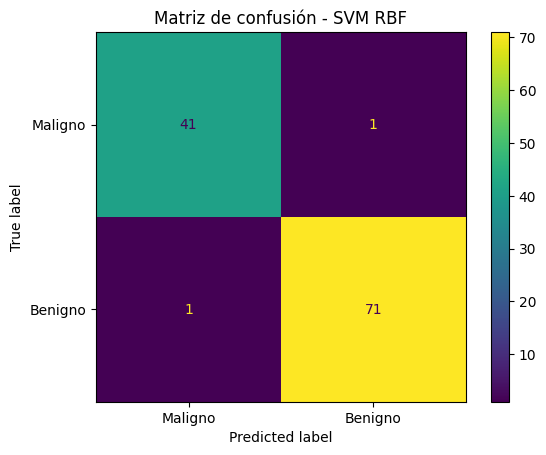

[[41  1]
 [ 1 71]]


In [9]:
# 9. Matriz de confusión del modelo con mejor F1-score

if f1_rbf >= f1_lineal:
    mejor_pred = y_pred_rbf
    mejor_nombre = "SVM RBF"
else:
    mejor_pred = y_pred_lineal
    mejor_nombre = "SVM Lineal"

cm = confusion_matrix(y_test, mejor_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Maligno", "Benigno"]
)

disp.plot()
plt.title(f"Matriz de confusión - {mejor_nombre}")
plt.show()

print(cm)


In [10]:
# 10. Modificación del hiperparámetro C en SVM RBF

valores_C = [0.1, 1, 10]
resultados_C = []

for C in valores_C:
    modelo = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=C))
    ])

    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)

    resultados_C.append({
        "C": C,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1-score": f1_score(y_test, pred)
    })

pd.DataFrame(resultados_C).round(4)


,C,Accuracy,Precision,Recall,F1-score
0,0.1,0.9474,0.9459,0.9722,0.9589
1,1.0,0.9825,0.9861,0.9861,0.9861
2,10.0,0.9737,0.9859,0.9722,0.9790


In [11]:
# 11. Escalamiento para K-Means
# La variable objetivo NO se usa para entrenar K-Means.

scaler_kmeans = StandardScaler()
X_scaled = scaler_kmeans.fit_transform(X)

print(X_scaled.shape)


(569, 30)


In [12]:
# 12. Evaluar diferentes valores de k con método del codo y Silhouette Score

inercias = []
silhouettes = []

valores_k = range(2, 7)

for k in valores_k:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    clusters_temp = kmeans.fit_predict(X_scaled)

    inercias.append(kmeans.inertia_)
    silhouettes.append(
        silhouette_score(X_scaled, clusters_temp)
    )

evaluacion_k = pd.DataFrame({
    "k": list(valores_k),
    "Inercia": inercias,
    "Silhouette Score": silhouettes
})

evaluacion_k.round(4)


,k,Inercia,Silhouette Score
0,2,11595.5266,0.3434
1,3,10061.7978,0.3144
2,4,9258.9891,0.2833
3,5,8558.6607,0.1582
4,6,7970.2638,0.1604


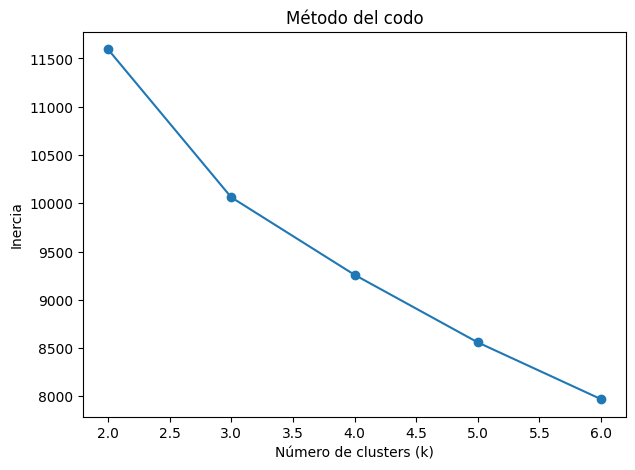

In [13]:
# 13. Gráfica del método del codo

plt.figure(figsize=(7, 5))
plt.plot(list(valores_k), inercias, marker="o")

plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del codo")

plt.show()


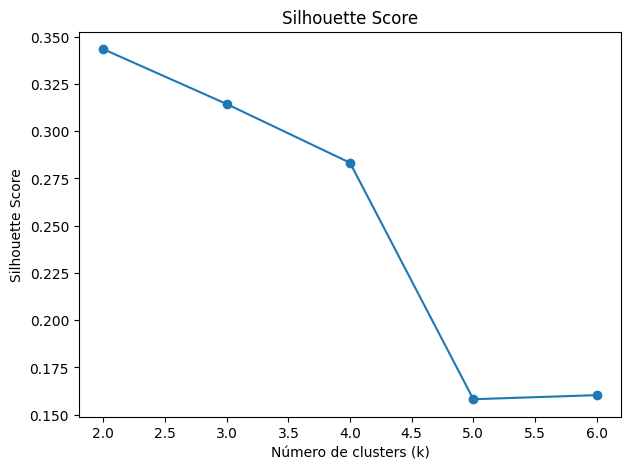

In [14]:
# 14. Gráfica de Silhouette Score

plt.figure(figsize=(7, 5))
plt.plot(list(valores_k), silhouettes, marker="o")

plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")

plt.show()


In [15]:
# 15. Modelo K-Means final con k = 2

kmeans_final = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans_final.fit_predict(X_scaled)

df_clusters = X.copy()
df_clusters["Cluster"] = clusters

df_clusters.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Cluster
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [16]:
# 16. Tamaño de cada cluster

tamano_clusters = (
    df_clusters["Cluster"]
    .value_counts()
    .sort_index()
)

tamano_clusters


Cluster
0    375
1    194
Name: count, dtype: int64

In [17]:
# 17. Promedio de variables principales por cluster

variables_principales = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean concavity",
    "mean concave points"
]

resumen_clusters = (
    df_clusters.groupby("Cluster")[variables_principales]
    .mean()
    .round(3)
)

resumen_clusters["Tamaño"] = tamano_clusters

resumen_clusters


,mean radius,mean texture,mean perimeter,mean area,mean concavity,mean concave points,Tamaño
Cluster,,,,,,,
0,12.427,18.262,79.820,486.772,0.043,0.026,375
1,17.415,21.275,115.453,979.857,0.178,0.093,194


In [18]:
# 18. PCA para reducir los datos a dos dimensiones

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": clusters
})

print("Varianza explicada:")
print(pca.explained_variance_ratio_)

print("\nVarianza acumulada:")
print(pca.explained_variance_ratio_.sum())


Varianza explicada:
[0.44272026 0.18971182]

Varianza acumulada:
0.6324320765155944


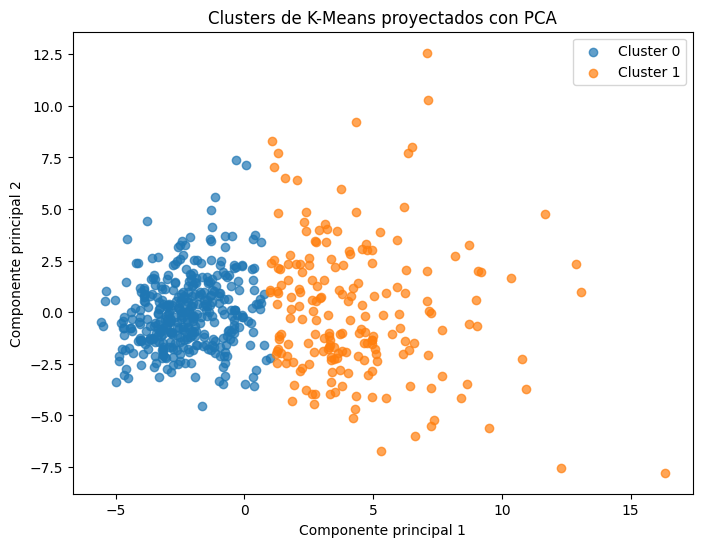

In [19]:
# 19. Visualización de clusters con PCA

plt.figure(figsize=(8, 6))

for cluster in np.unique(clusters):
    plt.scatter(
        pca_df.loc[pca_df["Cluster"] == cluster, "PC1"],
        pca_df.loc[pca_df["Cluster"] == cluster, "PC2"],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("Clusters de K-Means proyectados con PCA")
plt.legend()

plt.show()


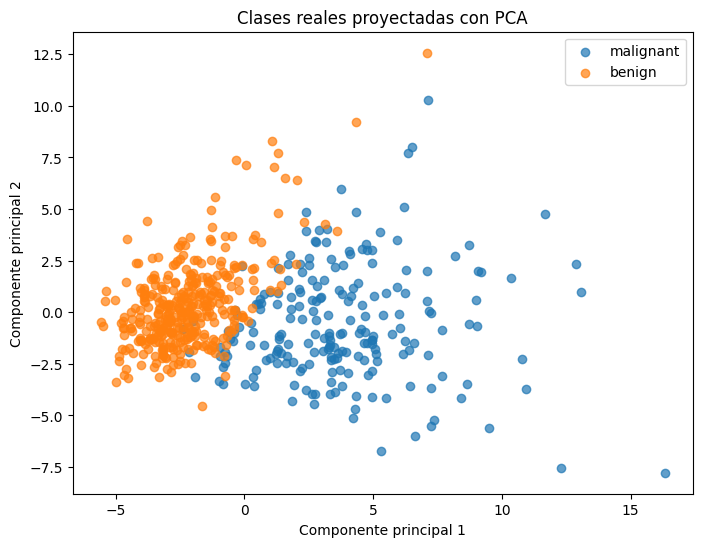

In [20]:
# 20. Visualización de clases reales con PCA
# Las etiquetas reales solo se usan aquí para comparación visual.

pca_real = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Clase real": y_real.values
})

plt.figure(figsize=(8, 6))

for clase in np.unique(y_real):
    plt.scatter(
        pca_real.loc[pca_real["Clase real"] == clase, "PC1"],
        pca_real.loc[pca_real["Clase real"] == clase, "PC2"],
        label=cancer.target_names[clase],
        alpha=0.7
    )

plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("Clases reales proyectadas con PCA")
plt.legend()

plt.show()


In [21]:
# 21. Comparación de clusters con las clases reales

comparacion = pd.crosstab(
    clusters,
    y_real,
    rownames=["Cluster"],
    colnames=["Clase real"]
)

comparacion.columns = ["Maligno", "Benigno"]

comparacion


,Maligno,Benigno
Cluster,,
0,36,339
1,176,18


In [22]:
# 22. Resultados finales resumidos

print("MEJOR MODELO SVM:", mejor_nombre)
print()

print("Resultados SVM:")
display(resultados_svm.round(4))

print("\nEvaluación de K-Means:")
display(evaluacion_k.round(4))

print("\nComparación de clusters con clases reales:")
display(comparacion)


MEJOR MODELO SVM: SVM RBF

Resultados SVM:


,Modelo SVM,Kernel,Accuracy,Precision,Recall,F1-score
0,Modelo 1,Lineal,0.9737,0.9859,0.9722,0.9790
1,Modelo 2,RBF,0.9825,0.9861,0.9861,0.9861



Evaluación de K-Means:


,k,Inercia,Silhouette Score
0,2,11595.5266,0.3434
1,3,10061.7978,0.3144
2,4,9258.9891,0.2833
3,5,8558.6607,0.1582
4,6,7970.2638,0.1604



Comparación de clusters con clases reales:


,Maligno,Benigno
Cluster,,
0,36,339
1,176,18


## Interpretación final

El modelo SVM permite predecir una clase conocida, benigno o maligno, utilizando las características numéricas de los tumores. El kernel RBF suele presentar el mejor desempeño en este conjunto de datos.

K-Means trabaja sin utilizar la variable objetivo y permite identificar grupos naturales según la similitud entre las observaciones. Los clusters encontrados presentan una correspondencia parcial con las clases reales, pero no tienen por qué coincidir exactamente porque K-Means agrupa por distancia y no por etiquetas conocidas.

El aprendizaje supervisado es adecuado cuando se desea predecir una categoría conocida. El aprendizaje no supervisado es útil cuando se busca explorar patrones o estructuras sin etiquetas previas.
